<a href="https://colab.research.google.com/github/oluwapelumi1/ACCESS-SAP-DATA-Science-Track/blob/main/Final%20Capstone%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Final Capstone Project - Supervised Learning & Live Presentation**
**using the datasets:🏥 Medical Insurance Cost Dataset**

# **Project Objectives**
By the end of this project, you should demonstrate the ability to:

* Perform end-to-end supervised learning

* Apply data cleaning, feature engineering, and preprocessing

* Build and compare multiple machine learning models

* Evaluate models using appropriate metrics

* Interpret model results and extract business-relevant insights

* Communicate findings clearly to a non-technical audience

In [50]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Make plots appear in notebook
%matplotlib inline

#Suppress warnings for Cleaner output
import warnings
warnings.filterwarnings('ignore')

In [51]:
#Read the dataset
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/insurance.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
#Get an idea of the dataset
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# **Initial Data Inspection**

In [54]:
#inspect the last five rows
df.tail()


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [55]:
#inspect the shape
df.shape
print(f"The shape of the dataset is:{df.shape}")


The shape of the dataset is:(1338, 7)


In [56]:
#check the columns
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

#



# **Data Understanding & Cleaning**

**using the datasets:🏥 Medical Insurance Cost Dataset**

* Load and inspect the dataset
* Handle missing values appropriately
* Identify and treat outliers (where necessary)
* Correct data types
* Clearly justify any data cleaning decisions




In [57]:
#ADDITION OF MISSING VALUES
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [58]:
df_clean=df.copy()

In [59]:
df_clean.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1333,False
1334,False
1335,False
1336,False


# **INSIGHT**


**The output df_clean.duplicated() indicates that there are no duplicate rows in the df_clean DataFrame, as all values are False.**



# **Exploratory Data Analysis (EDA)**

* Perform univariate and bivariate analysis
* Use visualizations to explore:
* Distributions
* Relationships
* Patterns and trends
* Highlight at least 3 meaningful insights from your analysis

In [60]:
df.head() # Display the first few rows

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


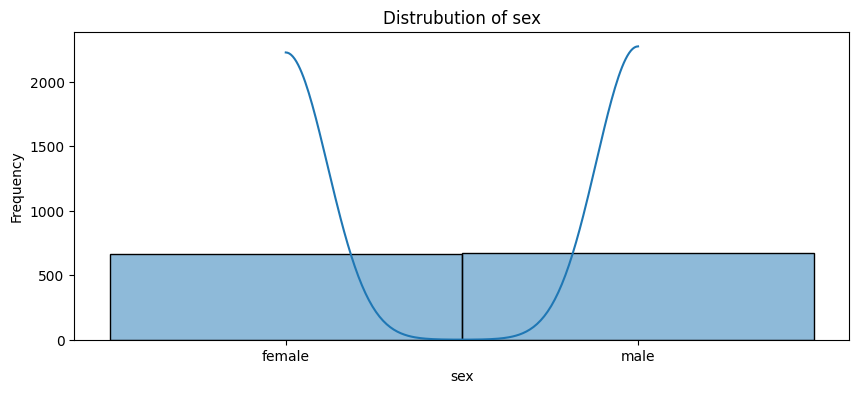

In [61]:
#histogram of the column 'region	'
plt.figure(figsize=(10, 4))
sns.histplot(df['sex'], bins=30, kde=True)
plt.title('Distrubution of sex')
plt.xlabel('sex')
plt.ylabel('Frequency')
plt.show();

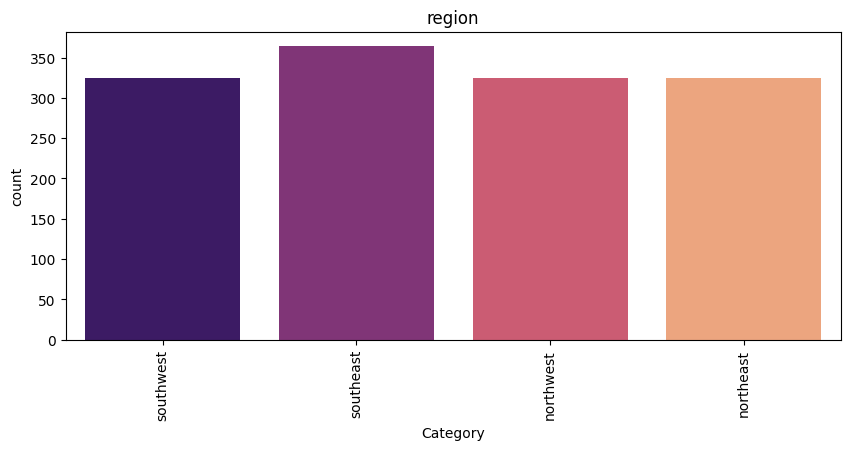

In [62]:
#category column -> distribution
plt.figure(figsize=(10,4))
sns.countplot(x = "region", data = df, palette = "magma")
plt.title("region")
plt.xlabel("Category")
plt.ylabel("count")
plt.xticks(rotation = 90)
plt.show();

**INSIGHT**

**The countplot for the 'region' column has been generated successfully. This visualization shows the distribution of individuals across different regions. It appears that the 'southeast' region has the highest number of individuals, followed closely by 'southwest', 'northwest', and 'northeast'.**

# **Bivariate Analysis**

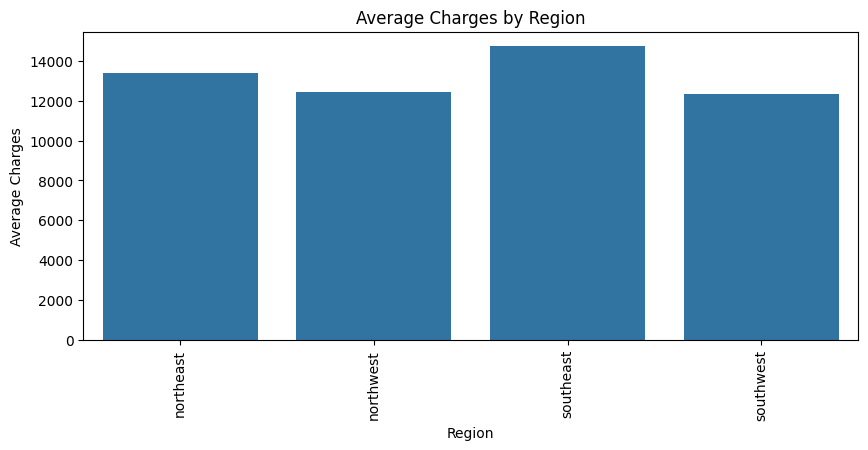

In [63]:
# Analyze 'charges' by 'region'
region_charges = df.groupby("region")["charges"].mean()
plt.figure(figsize = (10,4))
sns.barplot(x = region_charges.index, y = region_charges.values)
plt.title("Average Charges by Region")
plt.xlabel("Region")
plt.ylabel("Average Charges")
plt.xticks(rotation = 90)
plt.show();

# **INSIGHT**

**The bar plot successfully visualizes the average medical charges by region. From the plot, it's clear that the 'southeast' region has the highest average charges, followed by 'northeast', 'northwest', and 'southwest'.**



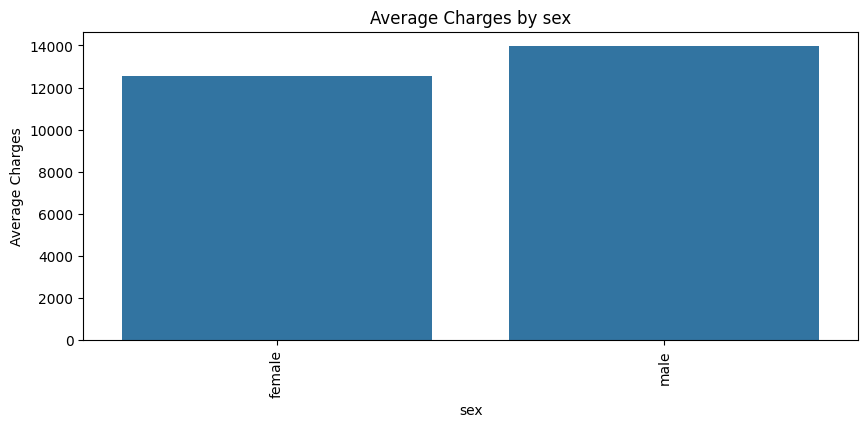

In [64]:
# Analyze 'charges' by 'sex'
region_charges = df.groupby("sex")["charges"].mean()
plt.figure(figsize = (10,4))
sns.barplot(x = region_charges.index, y = region_charges.values)
plt.title("Average Charges by sex")
plt.xlabel("sex")
plt.ylabel("Average Charges")
plt.xticks(rotation = 90)
plt.show();

# **INSIGHT**

 **The bar plot displaying 'Average Charges by Sex' shows that, on average, male individuals have slightly higher medical charges than female individuals in this dataset. However, the difference appears to be relatively small.**

# **Feature Engineering & Preprocessing**

* Create new meaningful features (if applicable)
* Identify categorical and numerical features

Apply:
Encoding for categorical variables
Scaling/normalization for numerical variables
Use pipelines where appropriate

# **Creating Boolean Flags**

In [65]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [83]:
# Flag high-value transactions
df_clean['is_high_value'] = df_clean['charges'] > 20000

# Flag properties that are either <1H OCEAN or INLAND
df_clean['is_smoker_male_or_female'] = df_clean['smoker'].isin(['<1H yes', 'no'])

In [84]:
df_clean.head(40)

,age,sex,bmi,children,smoker,region,charges,is_high_value,is_smoker_male_or_female
0,19,female,27.900,0,yes,southwest,16884.92400,False,False
1,18,male,33.770,1,no,southeast,1725.55230,False,True
2,28,male,33.000,3,no,southeast,4449.46200,False,True
3,33,male,22.705,0,no,northwest,21984.47061,True,True
4,32,male,28.880,0,no,northwest,3866.85520,False,True
5,31,female,25.740,0,no,southeast,3756.62160,False,True
6,46,female,33.440,1,no,southeast,8240.58960,False,True
7,37,female,27.740,3,no,northwest,7281.50560,False,True
8,37,male,29.830,2,no,northeast,6406.41070,False,True
9,60,female,25.840,0,no,northwest,28923.13692,True,True


In [76]:
# Find the maximum charge
highest_charge = df['charges'].max()
print(f"The highest charge recorded is: {highest_charge}")

# Display the row(s) corresponding to the highest charge
print("\nDetails of the individual(s) with the highest charge:")
display(df[df['charges'] == highest_charge])

The highest charge recorded is: 63770.42801

Details of the individual(s) with the highest charge:


,age,sex,bmi,children,smoker,region,charges
543,54,female,47.41,0,yes,southeast,63770.42801


In [86]:
# Group by 'sex' and 'smoker' and count the occurrences
smoker_by_sex = df.groupby(['sex', 'smoker']).size().unstack(fill_value=0)

print("Number of smokers and non-smokers by sex:")
print(smoker_by_sex)

# To find which sex smokes the most, we can look at the 'yes' column
most_smokers_sex = smoker_by_sex['yes'].idxmax()
num_most_smokers = smoker_by_sex['yes'].max()

print(f"\nThe sex with the most smokers is: {most_smokers_sex} with {num_most_smokers} smokers.")

Number of smokers and non-smokers by sex:
smoker   no  yes
sex             
female  547  115
male    517  159

The sex with the most smokers is: male with 159 smokers.


In [88]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['age', 'bmi', 'children', 'charges']
Categorical Columns: ['sex', 'smoker', 'region']
